# 01 — Simulated-truth accuracy & calibration (CLAUDE.md §9)

Simulate admixture with known local ancestry (census truth), fit hard-clamp EM on
the references, paint the admixed queries, and score. Strong-structure sims on the
true ARG (the easy regime); inferred-ARG and weak-structure regimes are where tree
accuracy becomes the binding constraint (the §9 head-to-head).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tspaint.experiments import admixture_experiment

r = admixture_experiment(T_admix=300, n_admix=6, n_ref=10, sequence_length=4e5,
                         f_A=0.5, max_iter=8, seed=1)
print('queries:', r['n_queries'], 'per-base accuracy:', round(r['accuracy'], 4))
print('Q:', np.round(r['Q'], 6).tolist(), 'pi:', np.round(r['pi'], 3).tolist())

queries: 12 per-base accuracy: 1.0
Q: [[-6e-05, 6e-05], [6.8e-05, -6.8e-05]] pi: [0.515, 0.485]


## Calibration (reliability diagram)

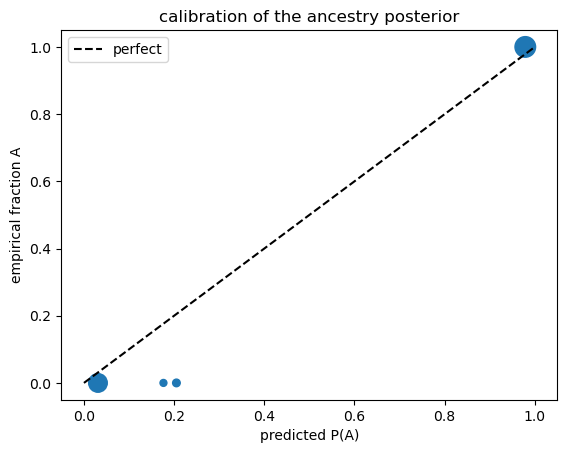

In [2]:
rel = r['reliability']
plt.plot([0, 1], [0, 1], 'k--', label='perfect')
plt.scatter(rel['pred'], rel['emp'], s=20 + 200 * rel['weight'] / rel['weight'].max())
plt.xlabel('predicted P(A)'); plt.ylabel('empirical fraction A'); plt.legend()
plt.title('calibration of the ancestry posterior'); plt.show()

## Discrimination vs. admixture age (§9): where the reference signal is lost

Balanced accuracy and mean confidence (not plain accuracy, which is misleading on a
lopsided truth) vs. admixture age. tspaint discriminates well at recent–moderate
admixture; at old admixture the reference signal is lost (balanced accuracy → chance,
confidence → 0) — admixed individuals sampled at the present coalesce among themselves
before the old pulse, severing the query→reference genealogical link. The crossover age
scales with Ne / sampling.

T_admix=   30  bal_acc=0.993  confidence=0.720  switches/q=0.1
T_admix=  300  bal_acc=0.927  confidence=0.358  switches/q=0.5
T_admix= 1000  bal_acc=0.500  confidence=0.148  switches/q=1.5
T_admix= 3000  bal_acc=0.500  confidence=0.184  switches/q=2.2


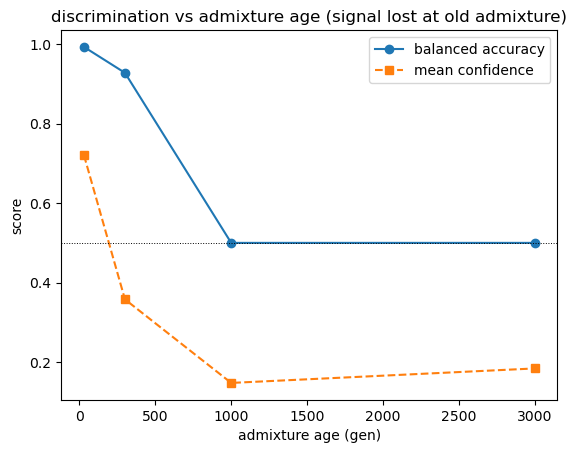

In [3]:
from tspaint.experiments import age_sweep
# more queries -> stable class fractions; balanced accuracy + confidence distinguish
# genuine discrimination from "the tree can't tell" (uninformative P~0.5). T_split is
# deep so only tract length varies with age.
common = dict(n_admix=12, n_ref=8, sequence_length=3e5, f_A=0.5, Ne=1000,
              T_split=10000, max_iter=5, seed=1)
ages = [30, 300, 1000, 3000]
rows = age_sweep(ages, infer=False, **common)
for row in rows:
    print(f"T_admix={row['T_admix']:5d}  bal_acc={row['balanced_accuracy']:.3f}  "
          f"confidence={row['confidence']:.3f}  switches/q={row['mean_true_switches']:.1f}")
plt.plot(ages, [row['balanced_accuracy'] for row in rows], 'o-', label='balanced accuracy')
plt.plot(ages, [row['confidence'] for row in rows], 's--', label='mean confidence')
plt.axhline(0.5, color='k', ls=':', lw=0.7)
plt.xlabel('admixture age (gen)'); plt.ylabel('score'); plt.legend()
plt.title('discrimination vs admixture age (signal lost at old admixture)'); plt.show()

## A painted haplotype vs. truth

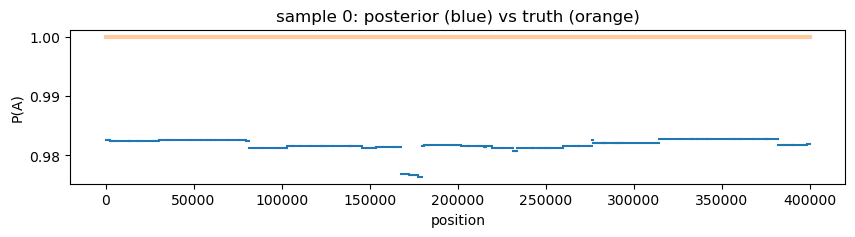

In [4]:
q = list(r['tracks'].keys())[0]
fig, ax = plt.subplots(figsize=(10, 2))
for seg in r['tracks'][q]:
    ax.plot([seg.left, seg.right], [seg.posterior[0]] * 2, 'C0')
for (l, rr2, st) in r['truth_states'][q]:
    ax.plot([l, rr2], [1 - st] * 2, 'C1', lw=3, alpha=0.4)
ax.set_xlabel('position'); ax.set_ylabel('P(A)'); ax.set_title(f'sample {q}: posterior (blue) vs truth (orange)')
plt.show()